In [2]:
class label_encode:
    def __init__(self):
        self.label_id = {}
        self.inital_format = {"id" : 0, "count" : 1}
        self.cur_id = 0
    
    def encode(self, datas:list):
        return_labels = []
        for data in datas:
            ch = self.label_id.get(data)
            if ch is not None:
                self.label_id[data]["count"] += 1
                return_labels.append(self.label_id[data]["id"])
            else:
                self.label_id[data] = self.inital_format.copy()
                self.label_id[data]["id"] = self.cur_id
                return_labels.append(self.label_id[data]["id"])
                self.cur_id += 1

        return return_labels

        
    def __call__(self, datas):
        return self.encode(datas)

In [3]:
# !pip install seaborn
# !pip install openpyxl
# !pip install pandas
# !pip install scipy
# !pip install xgboost
# !pip install scikit-learn

In [4]:
import pandas as pd

xlsx = pd.read_excel("ar-2017-2018.xlsx", "Anonymised register")
xlsx = xlsx[xlsx['Patient age at treatment'] != 999]
print(xlsx.isnull().sum())
print(xlsx.isnull().any())
print(xlsx.isnull().sum().sum())

Patient age at treatment                                  0
Total number of previous IVF cycles                       0
Total number of previous DI cycles                        0
Total number of previous pregnancies - IVF and DI    124264
Total number of previous live births - IVF or DI      62652
                                                      ...  
Heart three delivery date                            166867
Patient ethnicity                                         0
Partner ethnicity                                         0
Partner Type                                           7508
Partner age                                           14264
Length: 61, dtype: int64
Patient age at treatment                             False
Total number of previous IVF cycles                  False
Total number of previous DI cycles                   False
Total number of previous pregnancies - IVF and DI     True
Total number of previous live births - IVF or DI      True
                    

In [5]:
xlsx.head()

,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Total number of previous pregnancies - IVF and DI,Total number of previous live births - IVF or DI,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,...,Heart three weeks gestation,Heart three birth outcome,Heart three birth weight,Heart three sex,Heart three birth congenital abnormalities,Heart three delivery date,Patient ethnicity,Partner ethnicity,Partner Type,Partner age
0,45-50,3,0,0.0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Black,Other,Male,NaN
1,18-34,0,0,NaN,NaN,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,Other,NaN,NaN
3,18-34,0,0,NaN,NaN,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,White,Male,18-34
4,18-34,1,0,NaN,0,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,White,Male,18-34
5,40-42,0,0,NaN,NaN,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,White,Male,40-42


In [6]:
xlsx.columns

Index(['Patient age at treatment', 'Total number of previous IVF cycles',
       'Total number of previous DI cycles',
       'Total number of previous pregnancies - IVF and DI',
       'Total number of previous live births - IVF or DI',
       'Causes of infertility - tubal disease',
       'Causes of infertility - ovulatory disorder',
       'Causes of infertility - male factor',
       'Causes of infertility - patient unexplained',
       'Causes of infertility - endometriosis',
       'Main reason for producing embroys storing eggs', 'Stimulation used',
       'Egg donor age at registration', 'Sperm donor age at registration',
       'Donated embryo', 'Type of treatment - IVF or DI',
       'Specific treatment type', 'PGT-M treatment', 'PGT-A treatment',
       'Elective single embryo transfer', 'Egg source', 'Sperm source',
       'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)',
       'Fresh eggs collected', 'Fresh eggs stored (0/1)', 'Total eggs mixed',
       'Total embryos 

In [7]:
xlsx.count()

Patient age at treatment                             166947
Total number of previous IVF cycles                  166947
Total number of previous DI cycles                   166947
Total number of previous pregnancies - IVF and DI     42683
Total number of previous live births - IVF or DI     104295
                                                      ...  
Heart three delivery date                                80
Patient ethnicity                                    166947
Partner ethnicity                                    166947
Partner Type                                         159439
Partner age                                          152683
Length: 61, dtype: int64

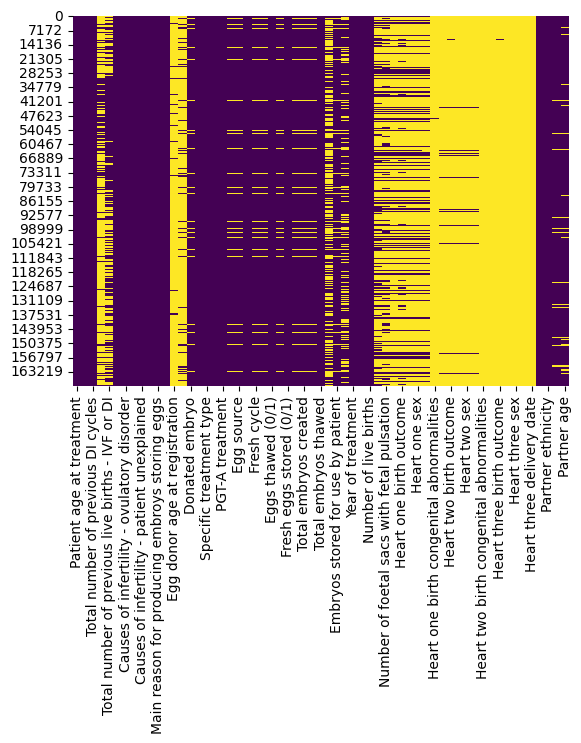

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 결측치 히트맵 시각화
sns.heatmap(xlsx.isnull(), cbar=False, cmap="viridis")
plt.show()

In [9]:
# 결측치가 있는 행 삭제
# xlsx_cleaned = xlsx.dropna()

# 결측치가 있는 열 삭제
xlsx_cleaned = xlsx.dropna(axis=1)

xlsx_cleaned.head()

,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,Main reason for producing embroys storing eggs,Stimulation used,...,PGT-M treatment,PGT-A treatment,Eggs thawed (0/1),Fresh eggs stored (0/1),Total embryos thawed,Year of treatment,Live birth occurrence,Number of live births,Patient ethnicity,Partner ethnicity
0,45-50,3,0,0,0,0,0,0,Embryo storage,0,...,0,0,0,0,0,2017,0,0,Black,Other
1,18-34,0,0,0,0,0,0,0,Donation,1,...,0,0,0,0,0,2018,0,0,White,Other
3,18-34,0,0,0,0,1,0,0,Treatment - IVF,1,...,0,0,0,0,0,2018,0,0,White,White
4,18-34,1,0,0,0,1,0,0,Treatment - IVF,0,...,0,0,0,0,1-5,2018,0,0,White,White
5,40-42,0,0,0,0,0,1,0,Treatment - IVF,1,...,0,0,0,0,0,2017,0,0,White,White


In [10]:

def automate_label_encoding(df):
    string_columns = df.select_dtypes(include=['object']).columns
    encodes = {}

    for column in string_columns:
        label_encoder = label_encode()
        labeled_data = label_encoder(df[column].astype(str).tolist())
        df.loc[:, column] = labeled_data
        
        encodes[column] = label_encoder
    return df, encodes

# 결측치 제거 후 라벨링 수행
xlsx_cleaned = xlsx.dropna(axis=1)
xlsx_labeled, encodes = automate_label_encoding(xlsx_cleaned)

xlsx_labeled.head()

,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,Main reason for producing embroys storing eggs,Stimulation used,...,PGT-M treatment,PGT-A treatment,Eggs thawed (0/1),Fresh eggs stored (0/1),Total embryos thawed,Year of treatment,Live birth occurrence,Number of live births,Patient ethnicity,Partner ethnicity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2017,0,0,0,0
1,1,1,0,0,0,0,0,0,1,1,...,0,0,0,0,0,2018,0,0,1,0
3,1,1,0,0,0,1,0,0,2,1,...,0,0,0,0,0,2018,0,0,1,1
4,1,2,0,0,0,1,0,0,2,0,...,0,0,0,0,1,2018,0,0,1,1
5,2,1,0,0,0,0,1,0,2,1,...,0,0,0,0,0,2017,0,0,1,1


In [11]:
encodes["Patient age at treatment"].label_id

{'45-50': {'id': 0, 'count': 4545},
 '18-34': {'id': 1, 'count': 68365},
 '40-42': {'id': 2, 'count': 23813},
 '38-39': {'id': 3, 'count': 24365},
 '35-37': {'id': 4, 'count': 38567},
 '43-44': {'id': 5, 'count': 7292}}

In [12]:
print(xlsx.columns)

Index(['Patient age at treatment', 'Total number of previous IVF cycles',
       'Total number of previous DI cycles',
       'Total number of previous pregnancies - IVF and DI',
       'Total number of previous live births - IVF or DI',
       'Causes of infertility - tubal disease',
       'Causes of infertility - ovulatory disorder',
       'Causes of infertility - male factor',
       'Causes of infertility - patient unexplained',
       'Causes of infertility - endometriosis',
       'Main reason for producing embroys storing eggs', 'Stimulation used',
       'Egg donor age at registration', 'Sperm donor age at registration',
       'Donated embryo', 'Type of treatment - IVF or DI',
       'Specific treatment type', 'PGT-M treatment', 'PGT-A treatment',
       'Elective single embryo transfer', 'Egg source', 'Sperm source',
       'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)',
       'Fresh eggs collected', 'Fresh eggs stored (0/1)', 'Total eggs mixed',
       'Total embryos 

In [13]:
xlsx_cleaned["Number of live births"]

0         0
1         0
3         0
4         0
5         0
         ..
169611    0
169612    0
169613    1
169614    1
169615    1
Name: Number of live births, Length: 166947, dtype: int64

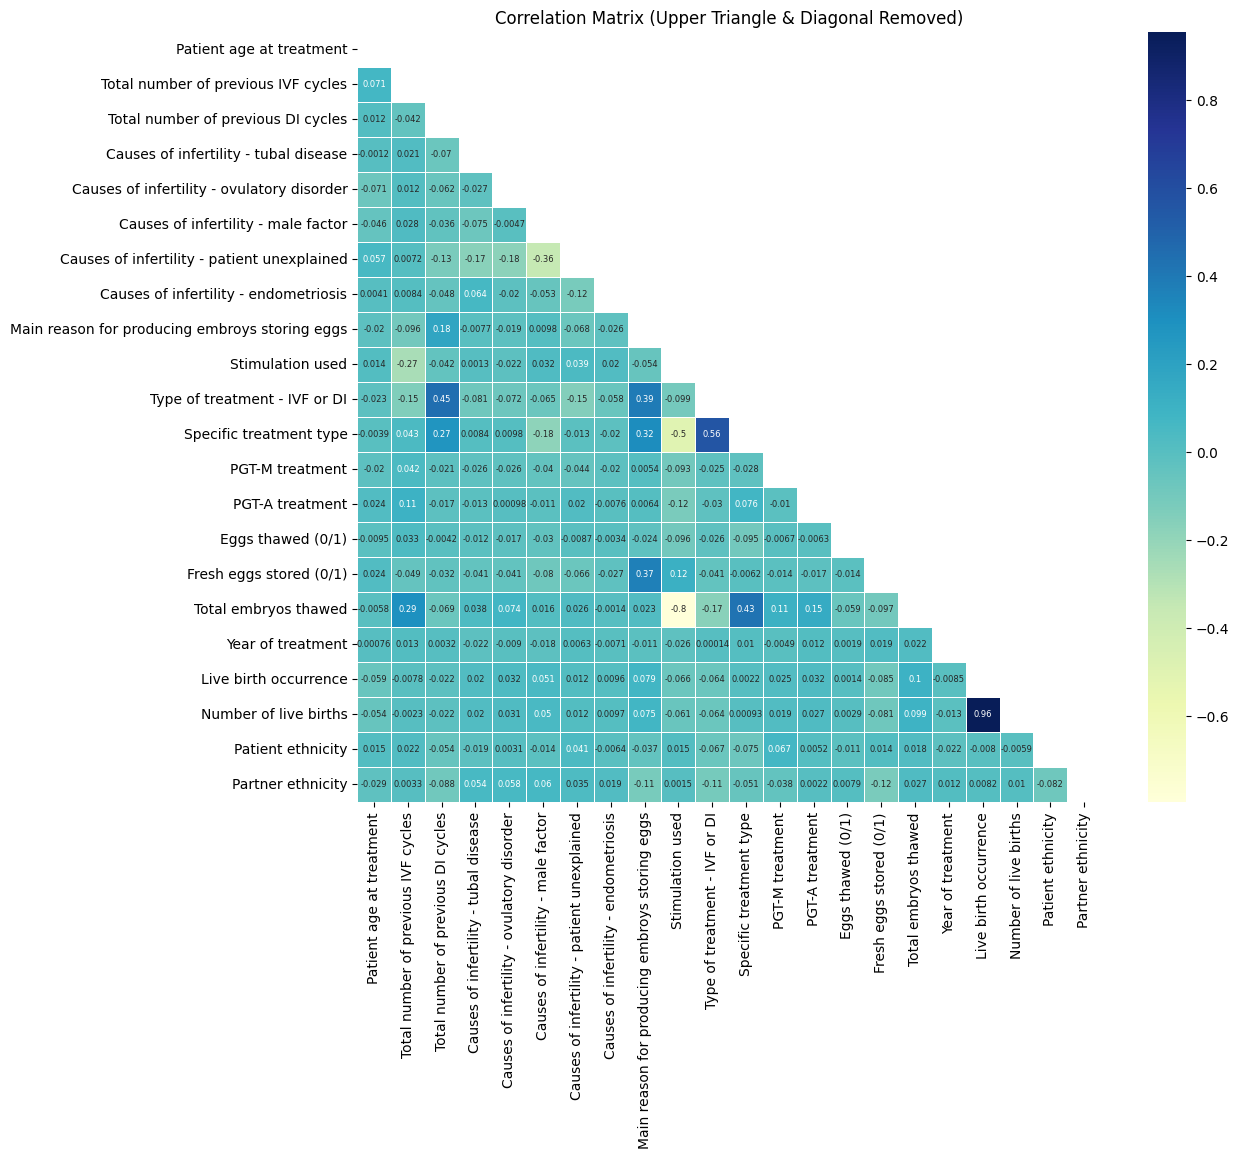

In [12]:
import numpy as np

correlation_matrix = xlsx_cleaned.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, mask=mask, annot_kws={"size": 6})
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask, annot_kws={"size": 6})
plt.title("Correlation Matrix (Upper Triangle & Diagonal Removed)")
plt.show()

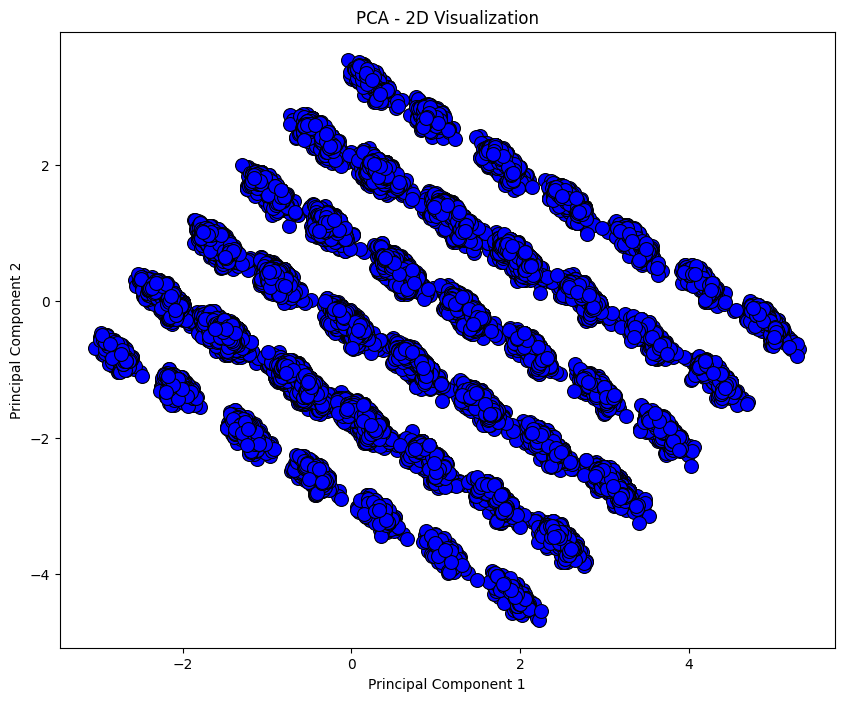

In [13]:
from sklearn.decomposition import PCA

# PCA 수행
pca = PCA(n_components=2)
principal_components = pca.fit_transform(xlsx_cleaned)

# 결과를 DataFrame으로 변환
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])

# PCA 시각화
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_df['Principal Component 1'], y=pca_df['Principal Component 2'], s=100, color='blue', edgecolor='black')
plt.title("PCA - 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [14]:
# # 각 변수의 히스토그램을 그리기
# xlsx_cleaned.hist(figsize=(14, 10), bins=20, color='skyblue', edgecolor='black')
# plt.suptitle("Histograms of Variables")
# plt.tight_layout()
# plt.show()

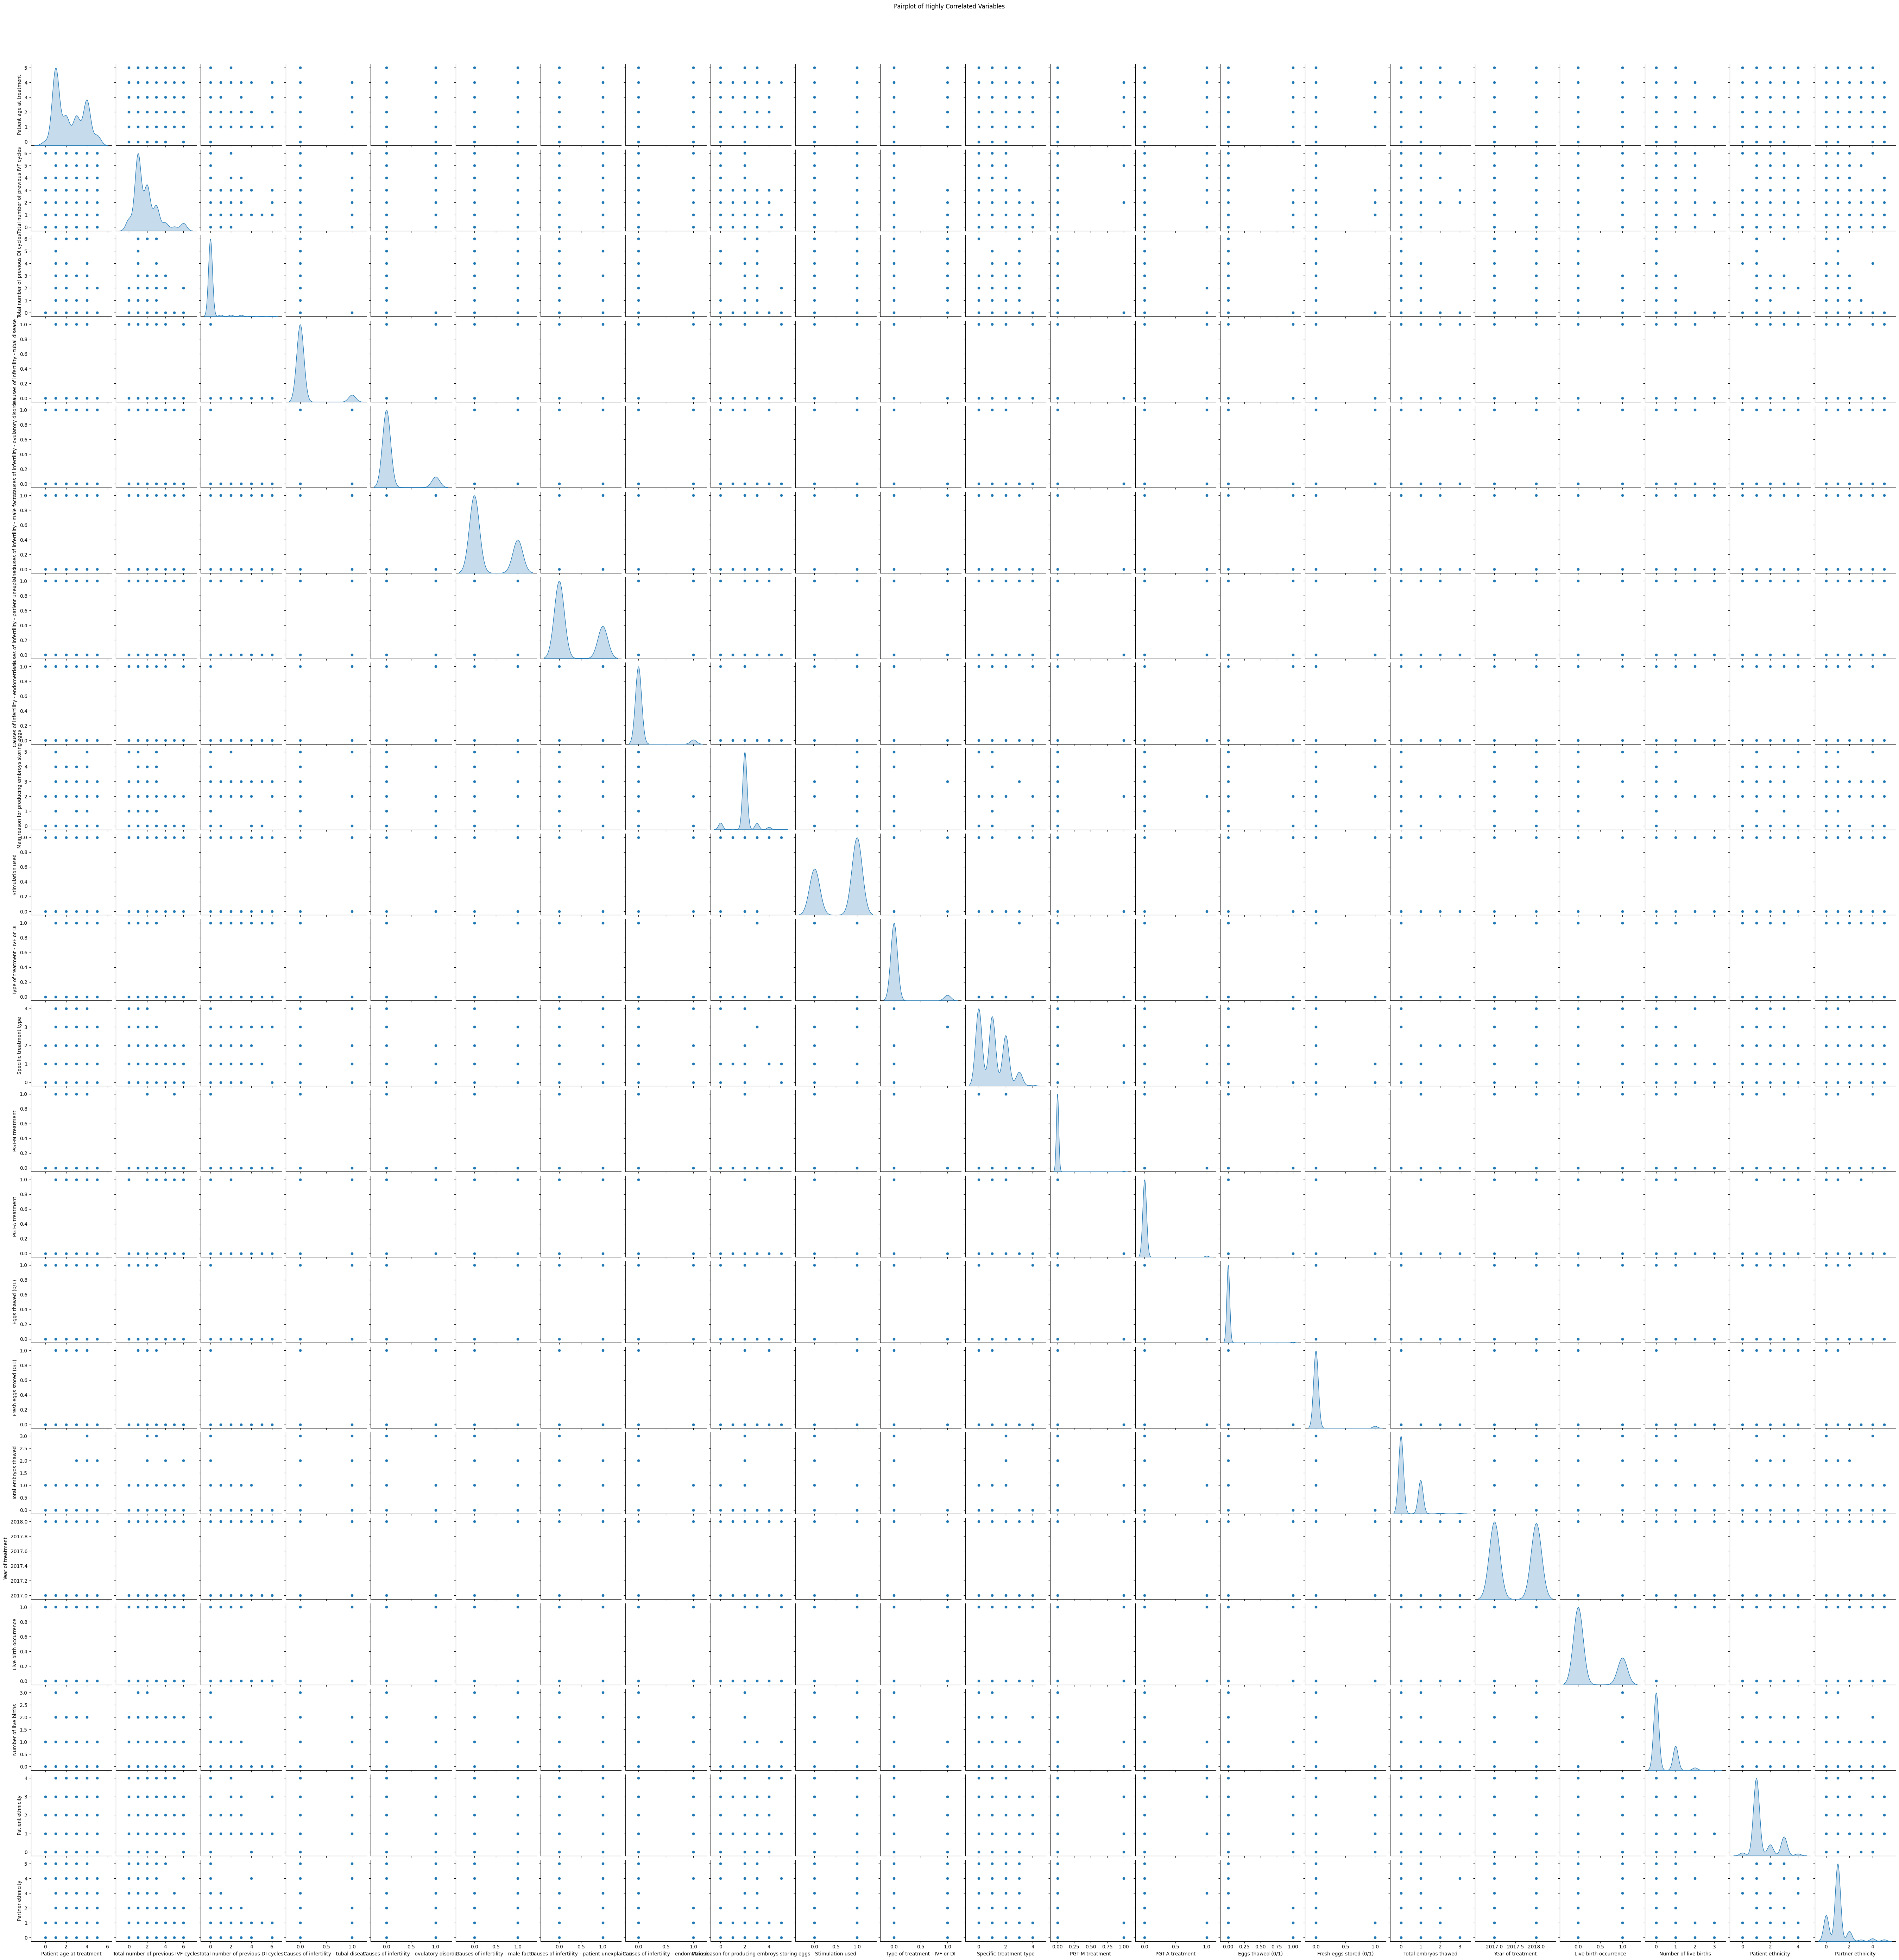

In [15]:
# 상관관계가 높은 변수 목록
high_correlation = correlation_matrix[correlation_matrix > 0.8]
high_corr_vars = high_correlation.index

sample_data = xlsx_cleaned.sample(n=1000, random_state=42)
sns.pairplot(sample_data[high_corr_vars], diag_kind="kde")
plt.suptitle("Pairplot of Highly Correlated Variables", y=1.02)
plt.show()
# plt.figure(figsize=(12, 10))
# sns.heatmap(high_correlation, annot=True, cmap='YlGnBu', linewidths=0.5, mask=mask, annot_kws={"size": 6})
# plt.title("Correlation Matrix with YlGnBu Color Map")
# plt.show()

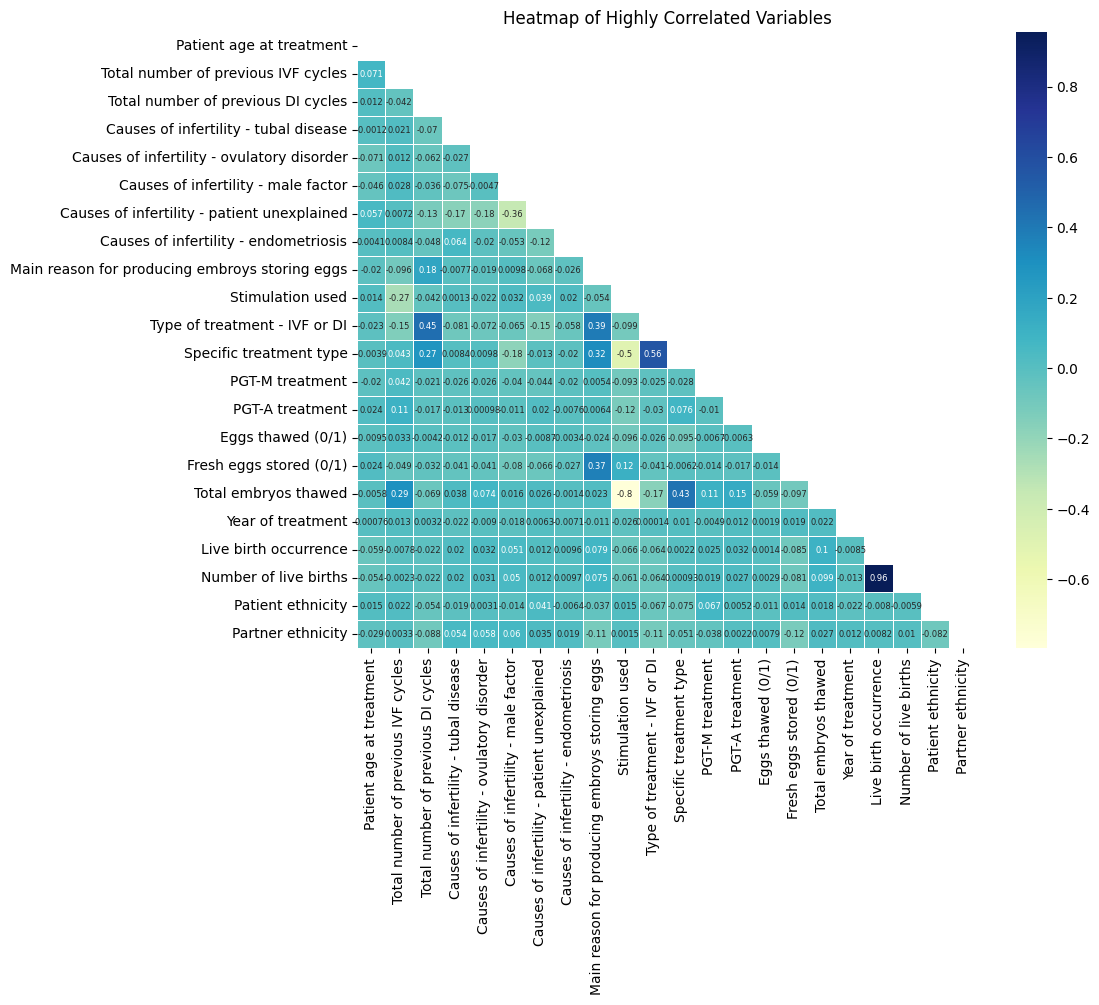

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, mask=mask, annot_kws={"size": 6})
# sns.heatmap(correlation_matrix[high_corr_vars].loc[high_corr_vars], annot=True, mask=mask, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap of Highly Correlated Variables")
plt.show()

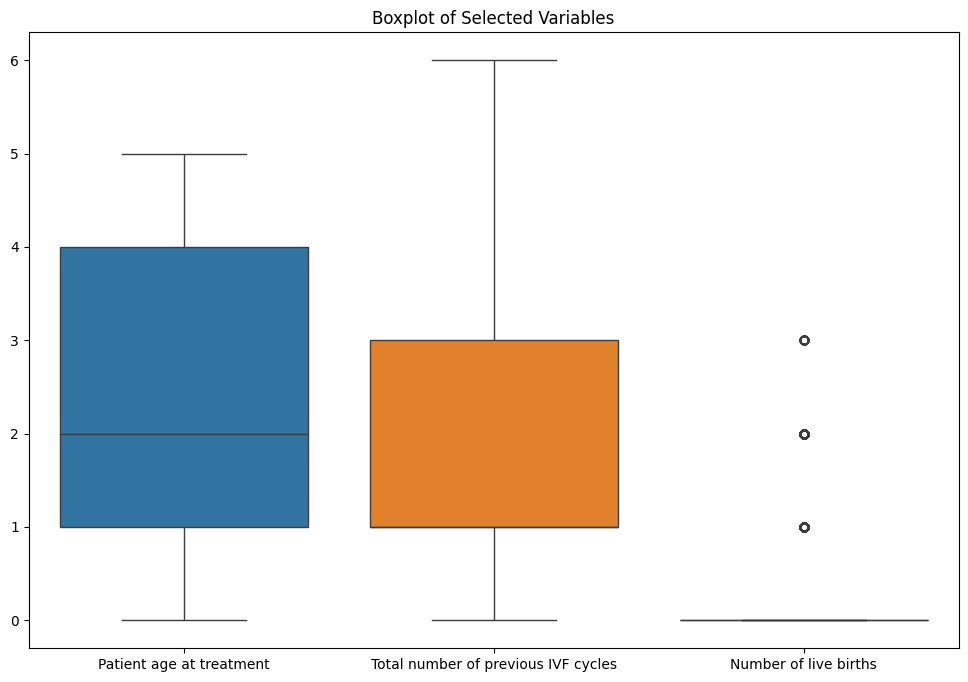

In [17]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=xlsx_cleaned[['Patient age at treatment', 'Total number of previous IVF cycles', 'Number of live births']])
plt.title("Boxplot of Selected Variables")
plt.show()

In [18]:
counts = xlsx_cleaned["Live birth occurrence"].value_counts()
print(counts)

Live birth occurrence
0    125932
1     41015
Name: count, dtype: int64


In [19]:
missing_values = xlsx_cleaned.isnull().sum()
print(missing_values)

Patient age at treatment                          0
Total number of previous IVF cycles               0
Total number of previous DI cycles                0
Causes of infertility - tubal disease             0
Causes of infertility - ovulatory disorder        0
Causes of infertility - male factor               0
Causes of infertility - patient unexplained       0
Causes of infertility - endometriosis             0
Main reason for producing embroys storing eggs    0
Stimulation used                                  0
Type of treatment - IVF or DI                     0
Specific treatment type                           0
PGT-M treatment                                   0
PGT-A treatment                                   0
Eggs thawed (0/1)                                 0
Fresh eggs stored (0/1)                           0
Total embryos thawed                              0
Year of treatment                                 0
Live birth occurrence                             0
Number of li

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix


X = xlsx_cleaned[['Patient age at treatment', 'Causes of infertility - tubal disease',
                  'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor',
                  'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis',
                  'Patient ethnicity', 'Partner ethnicity']]


# X = xlsx_cleaned[['Patient age at treatment', 'Total number of previous IVF cycles',
#                   'Total number of previous DI cycles', 'Causes of infertility - tubal disease',
#                   'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor',
#                   'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis',
#                   'Main reason for producing embroys storing eggs', 'Stimulation used',
#                   'Type of treatment - IVF or DI', 'Specific treatment type', 'PGT-M treatment',
#                   'PGT-A treatment', 'Eggs thawed (0/1)', 'Fresh eggs stored (0/1)',
#                   'Total embryos thawed',
#                   'Patient ethnicity', 'Partner ethnicity']]

# "Live birth occurrence" 레이블
y = xlsx_cleaned['Live birth occurrence']

X = X.astype("int32")

# 범주형 변수 인코딩 (Label Encoding 또는 OneHot Encoding)
categorical_columns = ['Causes of infertility - tubal disease', 'Causes of infertility - ovulatory disorder',
                       'Causes of infertility - male factor', 'Causes of infertility - patient unexplained',
                       'Causes of infertility - endometriosis', 'Main reason for producing embroys storing eggs',
                       'Stimulation used', 'Type of treatment - IVF or DI', 'Specific treatment type',
                       'PGT-M treatment', 'PGT-A treatment', 'Patient ethnicity', 'Partner ethnicity']

# 학습 데이터와 테스트 데이터로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 초기화
model = xgb.XGBClassifier(n_estimators=1000, random_state=42)

# 모델 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7512129380053908
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     25116
           1       0.34      0.00      0.01      8274

    accuracy                           0.75     33390
   macro avg       0.55      0.50      0.43     33390
weighted avg       0.65      0.75      0.65     33390



Live birth occurrence
0    25116
1     8274
Name: count, dtype: int64 

0
0    33285
1      105
Name: count, dtype: int64 



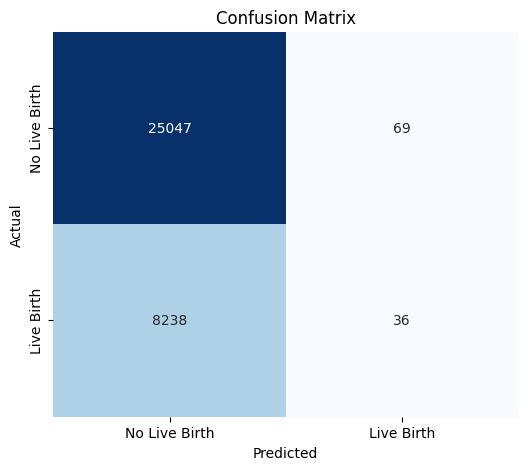

In [45]:
y_pred = pd.DataFrame(y_pred)

print(y_test.value_counts(), "\n")
print(y_pred.value_counts(), "\n")

# 혼동 행렬 출력
conf_matrix = confusion_matrix(y_test, y_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Live Birth', 'Live Birth'], yticklabels=['No Live Birth', 'Live Birth'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
y.value_counts()

Live birth occurrence
0    125932
1     41015
Name: count, dtype: int64

In [28]:
# plt.figure(figsize=(10, 8))
# sns.scatterplot(x=xlsx_cleaned.head().iloc[:, 0], y=xlsx_cleaned.head().iloc[:, 1])
# plt.title("Scatterplot of First Two Columns")
# plt.xlabel(xlsx_cleaned.columns[0])
# plt.ylabel(xlsx_cleaned.columns[1])
# plt.show()

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler

# 데이터 준비 (예시로 xlsx_cleaned 데이터 사용)
X = xlsx_cleaned[['Patient age at treatment', 'Causes of infertility - tubal disease',
                  'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor',
                  'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis',
                  'Patient ethnicity', 'Partner ethnicity']]

# , 'Year of treatment' 있고 없고 차이가 있음. 데이터의 상관관계는 없어 보이는데 아마 연도별로 데이터의 패턴이 바뀌는거 같은데?

# "Live birth occurrence" 레이블
y = xlsx_cleaned['Live birth occurrence']

# 학습 데이터와 테스트 데이터로 분할
X = X.astype("float32")


# 언더샘플링 적용
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# 결과 확인
print(y_resampled.value_counts())

X_train_full, X_test, y_train_full, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).cuda()
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).cuda()
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).cuda()
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).cuda()
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).cuda()
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


# 레이블 차원 변경
y_train_tensor = y_train_tensor.unsqueeze(1)  # (batch_size,) -> (batch_size, 1)
y_val_tensor = y_val_tensor.unsqueeze(1)      # (batch_size,) -> (batch_size, 1)
y_test_tensor = y_test_tensor.unsqueeze(1)    # (batch_size,) -> (batch_size, 1)


class Conv1DMLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_prob=0.2, use_layer_norm=False):
        super(Conv1DMLPModel, self).__init__()
        
        self.use_layer_norm = use_layer_norm  # Layer Normalization 사용 여부
        
        # Conv1D 레이어
        self.conv1d = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)  # Conv1D 출력에 대한 Batch Normalization
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Dropout 추가
        self.dropout = nn.Dropout(dropout_prob)
        
        # MLP 레이어
        self.fc1 = nn.Linear(32 * (input_dim // 2), hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)  # Fully Connected 레이어에 대한 Batch Normalization
        self.ln1 = nn.LayerNorm(hidden_dim)    # Layer Normalization
        
        self.fc2 = nn.Linear(hidden_dim, 1)  # num_classes=1로 설정 (이진 분류)

    def forward(self, x):
        # Conv1D 레이어
        x = x.unsqueeze(1)  # Conv1D는 (batch_size, channels, length) 형식을 요구하므로 차원 추가
        x = self.conv1d(x)
        x = self.bn1(x)  # Batch Normalization
        x = torch.relu(x)
        x = self.pool(x)
        
        # Dropout 적용
        x = self.dropout(x)
        
        # MLP 레이어
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc1(x)
        
        if self.use_layer_norm:
            x = self.ln1(x)  # Layer Normalization (옵션)
        else:
            x = self.bn2(x)  # Batch Normalization
        
        x = torch.relu(x)
        
        # Dropout 적용
        x = self.dropout(x)
        
        x = self.fc2(x)
        
        # 출력은 sigmoid 없이 로짓 값을 직접 반환
        return x

Live birth occurrence
0    41015
1    41015
Name: count, dtype: int64


In [37]:
from torch.utils.data import DataLoader, TensorDataset

# 데이터셋 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader 생성 (배치 크기 설정)
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# 모델 정의 (Conv1DMLPModel는 이전 코드와 동일)

# 모델 초기화
input_dim = X_train.shape[1]
model = Conv1DMLPModel(input_dim).cuda()

# 손실 함수와 최적화 기법 설정
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# 모델 학습
epochs = 200
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        # 모델 예측
        outputs = model(X_batch)
        
        # 손실 계산
        loss = criterion(outputs, y_batch)
        
        # 역전파
        loss.backward()
        
        # 가중치 업데이트
        optimizer.step()
        
        # 배치 손실 추가
        epoch_loss += loss.item()
    
    # 검증 데이터 평가
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {epoch_loss / len(train_loader):.4f}, Validation Loss: {val_loss / len(val_loader):.4f}")


# 테스트 데이터에 대한 평가
model.eval()
y_pred_list = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred = model(X_batch)
        y_pred = torch.sigmoid(y_pred)
        y_pred = (y_pred > 0.5).int()
        y_pred_list.append(y_pred.cpu().numpy())

# Flatten the predictions for evaluation
y_pred = np.vstack(y_pred_list)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Epoch [20/200], Train Loss: 0.6847, Validation Loss: 0.6808
Epoch [40/200], Train Loss: 0.6814, Validation Loss: 0.6794
Epoch [60/200], Train Loss: 0.6804, Validation Loss: 0.6785
Epoch [80/200], Train Loss: 0.6789, Validation Loss: 0.6773
Epoch [100/200], Train Loss: 0.6782, Validation Loss: 0.6765
Epoch [120/200], Train Loss: 0.6771, Validation Loss: 0.6759
Epoch [140/200], Train Loss: 0.6775, Validation Loss: 0.6752
Epoch [160/200], Train Loss: 0.6761, Validation Loss: 0.6751
Epoch [180/200], Train Loss: 0.6769, Validation Loss: 0.6752
Epoch [200/200], Train Loss: 0.6763, Validation Loss: 0.6747
Accuracy: 0.5880775326100207
              precision    recall  f1-score   support

           0       0.62      0.43      0.51      8161
           1       0.57      0.74      0.64      8245

    accuracy                           0.59     16406
   macro avg       0.60      0.59      0.58     16406
weighted avg       0.60      0.59      0.58     16406



In [40]:
def split_and_trim(array, chunk_size):
    num_chunks = len(array) // chunk_size
    trimmed_length = num_chunks * chunk_size  # 마지막 부분 제외
    trimmed_array = array[:int(trimmed_length)]  # 남은 부분 제거

    chunks = np.split(trimmed_array, num_chunks)
    return chunks

In [41]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    # y_pred = y_pred_tensor.detach().cpu() > 0.4
    y_pred = y_pred_tensor.detach().cpu() > 0.5

# 평가
accuracy = accuracy_score(y_test, y_pred.numpy())
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred.numpy()))
print("AUC-PR:", roc_auc_score(y_test, y_pred_tensor.cpu().numpy()))

Accuracy: 0.5235889308789468
              precision    recall  f1-score   support

           0       0.51      0.91      0.66      8161
           1       0.62      0.14      0.22      8245

    accuracy                           0.52     16406
   macro avg       0.56      0.53      0.44     16406
weighted avg       0.56      0.52      0.44     16406

AUC-PR: 0.616510918195809


In [42]:
from torch.nn import functional as F

sigmoid_tensor = F.sigmoid(y_pred_tensor.cpu())
rounded_tensor = (sigmoid_tensor * 10**4).round() / 10**4
rounded_tensor

tensor([[0.4227],
        [0.4971],
        [0.6265],
        ...,
        [0.5275],
        [0.5353],
        [0.6142]])

Live birth occurrence
1    8245
0    8161
Name: count, dtype: int64 

0    
False    14579
True      1827
Name: count, dtype: int64 



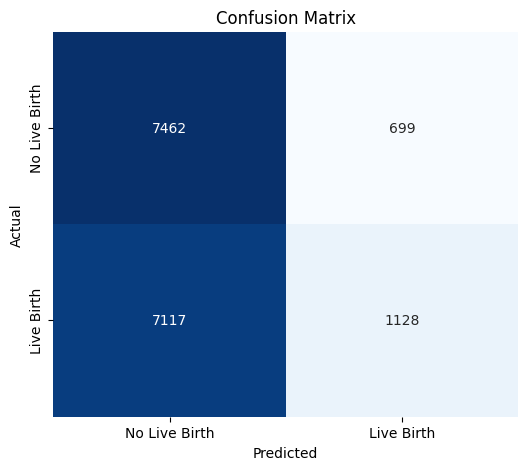

In [43]:
y_pred = pd.DataFrame(y_pred)

print(y_test.value_counts(), "\n")
print(y_pred.value_counts(), "\n")

# 혼동 행렬 출력
conf_matrix = confusion_matrix(y_test, y_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Live Birth', 'Live Birth'], yticklabels=['No Live Birth', 'Live Birth'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
https://github.com/helloNarehase/LG_Aimers_2025.git